# Word Clustering using Distance Metrics and Unsupervised Learning

**Course:** Artificial Intelligence

**Author:** Mehak Jan >  
**Tools:** Python, NLTK, Scikit-learn, NetworkX  

---

## OverviewIn this notebook an effort has been made to study the relationship between words and how they are related and connected to each other which cannot be gauged by just looking at them. This has been done by taking three novels and analysisng the words in them using data clustering
ath methods.


## 1. Data Collection and Preprocessing:

### Text Sources
The corpus was created by concatenating three literary works:
- *Dracula* — Bram Stoker  
- *Metamorphosis* — Franz Kafka  
- *Alice’s Adventures in Wonderland* — Lewis Carroll  

These texts were selected due to their rich vocabulary and narrative structure.


### Preprocessing Steps
The following preprocessing steps were applied to clean and normalize the corpus:

- Removal of Project Gutenberg headers and footers
- Lowercasing all text
- Tokenization into sentences using NLTK
- Removal of punctuation, digits, and extra whitespace
- Stop word removal
- Lemmatization to reduce words to base forms

After preprocessing, the final corpus contained approximately **400k–500k tokens**, providing
a robust dataset for semantic analysis.


In [4]:
#Step 1 load and clean the data

import os
import re
import nltk
from nltk.tokenize import sent_tokenize

# Download the NLTK tokenizer (only needed once)
#nltk.download('punkt')

# Specify the directory where the text files are stored
directory = r"C:\Users\mehak\OneDrive\Documents\ai_coursrwork"  

# Read and combine all text files
text_corpus = ""
for filename in os.listdir(directory):
    if filename.endswith(".txt"):
        with open(os.path.join(directory, filename), "r", encoding="utf-8") as file:
            text_corpus += file.read() + " "  # Concatenate with space

# Clean the text
text_corpus = text_corpus.lower()  # Convert to lowercase
text_corpus = re.sub(r'\s+', ' ', text_corpus)  # Remove extra spaces
text_corpus = re.sub(r'[^a-z\s]', '', text_corpus)  # Keep only letters and spaces

# Split text into sentences
sentences = sent_tokenize(text_corpus)

# Display sample output
#print(f"Total sentences: {len(sentences)}")
#print("Sample sentences:", sentences[:5])  # Print first 5 sentences


## 2. Word Selection and Linguistic Categorization 

After preprocessing, the corpus was analyzed to identify the most frequently occurring
meaningful words. Stop words such as articles and conjunctions were removed to ensure
that only **content wors**—words that carry semantic meaingwere retainedned.

From the filtered corpus, the **top 100 most frequent content words** were selected.
This subset was chosen to balance richness of information with computational efficiency.

The selected words were then manually categorized into linguistic groups such as verbs,
nouns, adjectives, and other relevant classes. This categorization helped in understanding
the distribution of different word types and provided insight into how language is used
across the combined texts.


In [6]:
#Step 2 selecting the 100 Most Common Words
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

# Download necessary NLTK resources
#nltk.download('punkt')
#nltk.download('stopwords')

# Tokenize text into words
words = word_tokenize(text_corpus)

# Remove stopwords and single-character words
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word not in stop_words and len(word) > 1]

# Count word frequency
word_freq = Counter(filtered_words)

# Select the 100 most common words
common_words = [word for word, _ in word_freq.most_common(100)]

# Display the most common words
print("Most common words:", common_words)


Most common words: ['said', 'could', 'would', 'one', 'must', 'us', 'see', 'may', 'time', 'shall', 'know', 'come', 'came', 'back', 'went', 'go', 'like', 'room', 'even', 'van', 'way', 'work', 'door', 'helsing', 'well', 'seemed', 'little', 'much', 'project', 'gutenberg', 'think', 'took', 'though', 'good', 'made', 'away', 'hand', 'get', 'dear', 'saw', 'looked', 'face', 'man', 'lucy', 'mina', 'night', 'eyes', 'great', 'tell', 'things', 'old', 'make', 'without', 'poor', 'gregor', 'thought', 'look', 'sleep', 'first', 'got', 'found', 'day', 'jonathan', 'dr', 'long', 'might', 'friend', 'say', 'something', 'let', 'take', 'two', 'quite', 'alice', 'last', 'asked', 'still', 'yet', 'life', 'never', 'professor', 'head', 'oh', 'god', 'told', 'count', 'began', 'round', 'ever', 'men', 'place', 'nothing', 'done', 'house', 'till', 'open', 'knew', 'full', 'right', 'left']


### Observations:
As one can see below are the results, which are as follows:
- Verbs are forming the largest category as this is a dialog based text.
- One can also observe proper nouns which emphasizes character based novel.
- Lastly abstract nouns and modifiers reflect thematic and emotional patterns.

Now one has the dataset for semantic distance modelling.

## 3. Distance Metric Construction 

To quantify semantic similarity between words, two complementary distance measures were used.


### 1. Sentence-Level Co-occurrence
Sentence-level co-occurrence refers to the appearance of two or more words or entities within the same sentence, serving as a key indicator of a strong potential semantic or topical relationship between them in natural language processing (NLP). 

**Key insights:**
- Strong character associations are noticed (e.g., *van* and *helsing*)
- Thematic word groupings (e.g., *sleep* and *eyes*)
- Isolation of novel-specific vocabulary

### 2. Average Positional Distance:
"Average positional distance" typically refers to the mean difference in the sequential location of linguistic elements within a specific context, such as a sentence. This concept is used in both human language processing studies and computational models (like AI text embeddings) to measure relationships and complexity. 

**Key insights:**
- Modal verbs showed small inter-word distances.
- Related concepts appeared closer together.
- Character names from different novels exhibited large distances.

### Final Hybrid Distance Metric
A hybrid distance metric was constructed as:

\[
D_{ij} = \frac{1}{1 + \text{co-occurrence}_{ij}} + \text{avg\_positional\_distance}_{ij}
\]

This formulation rewards frequent co-occurrence while penalizing large positional separation.

In [8]:
#Step 3 Measuring Word Distance/Similarity

import numpy as np
from itertools import combinations

# Create a dictionary to store word co-occurrence counts
word_cooccurrence = {word: {w: 0 for w in common_words} for word in common_words}

# Count how often words appear together in the same sentence
for sentence in sentences:
    sentence_words = set(word_tokenize(sentence))  # Tokenize sentence
    for word1, word2 in combinations(common_words, 2):
        if word1 in sentence_words and word2 in sentence_words:
            word_cooccurrence[word1][word2] += 1
            word_cooccurrence[word2][word1] += 1  # Ensure symmetry

# Create a dictionary to store average positional distances
word_positions = {word: [] for word in common_words}

# Track positions of each word in the text
tokens = word_tokenize(text_corpus)
for index, word in enumerate(tokens):
    if word in word_positions:
        word_positions[word].append(index)

# Compute average positional distance
word_distances = {word: {w: float('inf') for w in common_words} for word in common_words}
for word1, word2 in combinations(common_words, 2):
    if word_positions[word1] and word_positions[word2]:
        distances = [abs(i - j) for i in word_positions[word1] for j in word_positions[word2]]
        avg_distance = np.mean(distances)
        word_distances[word1][word2] = avg_distance
        word_distances[word2][word1] = avg_distance  # Ensure symmetry

# Display sample output
print("Sample word co-occurrence:", dict(list(word_cooccurrence.items())[:5]))
print("Sample word distances:", dict(list(word_distances.items())[:5]))



Most common words: ['said', 'could', 'would', 'one', 'must', 'us', 'see', 'may', 'time', 'shall', 'know', 'come', 'came', 'back', 'went', 'go', 'like', 'room', 'even', 'van', 'way', 'work', 'door', 'helsing', 'well', 'seemed', 'little', 'much', 'project', 'gutenberg', 'think', 'took', 'though', 'good', 'made', 'away', 'hand', 'get', 'dear', 'saw', 'looked', 'face', 'man', 'lucy', 'mina', 'night', 'eyes', 'great', 'tell', 'things', 'old', 'make', 'without', 'poor', 'gregor', 'thought', 'look', 'sleep', 'first', 'got', 'found', 'day', 'jonathan', 'dr', 'long', 'might', 'friend', 'say', 'something', 'let', 'take', 'two', 'quite', 'alice', 'last', 'asked', 'still', 'yet', 'life', 'never', 'professor', 'head', 'oh', 'god', 'told', 'count', 'began', 'round', 'ever', 'men', 'place', 'nothing', 'done', 'house', 'till', 'open', 'knew', 'full', 'right', 'left']
Sample word co-occurrence: {'said': {'said': 0, 'could': 1, 'would': 1, 'one': 1, 'must': 1, 'us': 1, 'see': 1, 'may': 1, 'time': 1, 'sh

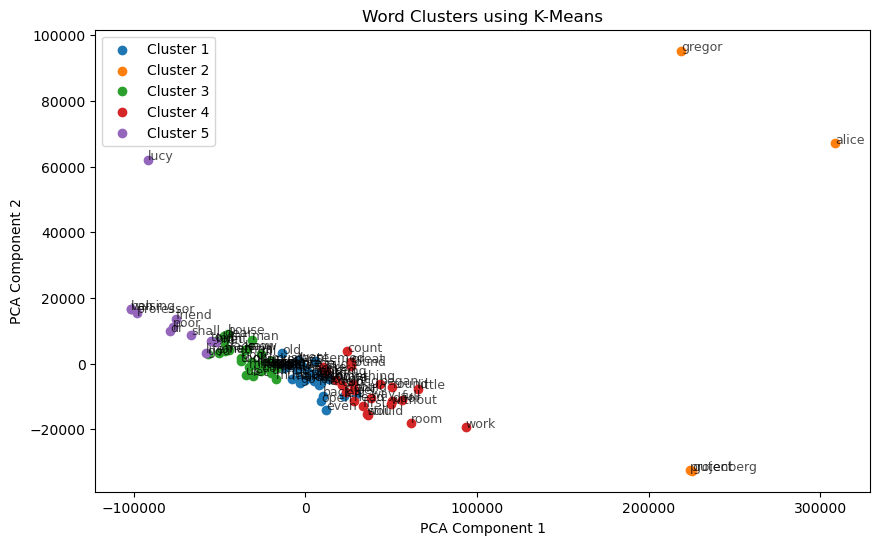

Shortest paths from 'said': {'said': 0, 'could': 70519.75047373623, 'would': 73606.52076373306, 'one': 66533.04017833211, 'must': 64864.593771510816}
Shortest paths from 'could': {'said': 70519.75047373623, 'could': 0, 'would': 71063.733672585, 'one': 68993.31068669367, 'must': 67050.04160580765}
Shortest paths from 'would': {'said': 73606.52076373306, 'could': 71063.733672585, 'would': 0, 'one': 70376.48376401755, 'must': 68045.92978561943}
Shortest paths from 'one': {'said': 66533.04017833211, 'could': 68993.31068669367, 'would': 70376.48376401755, 'one': 0, 'must': 63969.10131487701}
Shortest paths from 'must': {'said': 64864.593771510816, 'could': 67050.04160580765, 'would': 68045.92978561943, 'one': 63969.10131487701, 'must': 0}


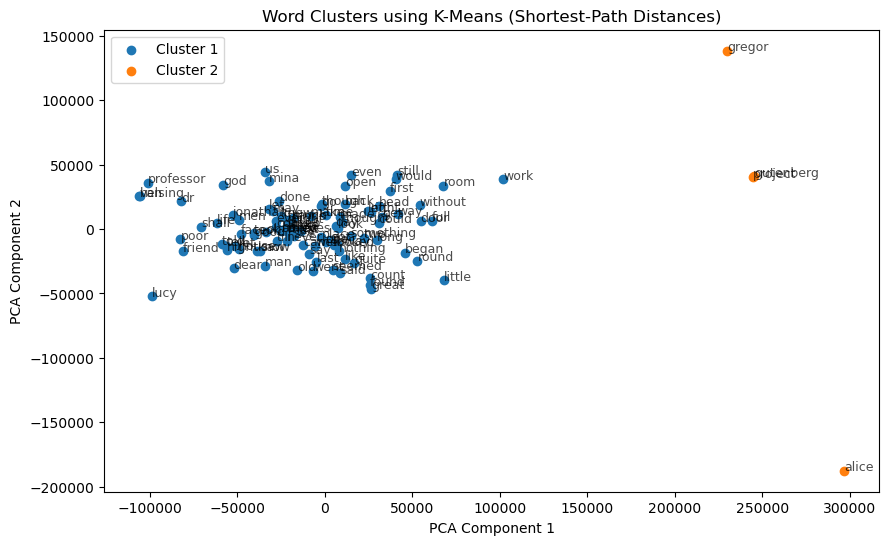

In [9]:
#Step 4 Perform K-Means Clustering
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Convert word distance dictionary into a symmetric matrix
words_list = list(common_words)
distance_matrix = np.array([[word_distances[w1][w2] for w2 in words_list] for w1 in words_list])

# Replace 'inf' values with a large number (since some words may never appear together)
max_distance = np.nanmax(distance_matrix[distance_matrix != float('inf')])
distance_matrix[distance_matrix == float('inf')] = max_distance

# Apply K-Means clustering
num_clusters = 5  # Adjust as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(distance_matrix)

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(distance_matrix)

# Plot clusters
plt.figure(figsize=(10, 6))
for i in range(num_clusters):
    cluster_points = reduced_data[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {i+1}")

for i, word in enumerate(words_list):
    plt.annotate(word, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=9, alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.title("Word Clusters using K-Means")
plt.show()

import heapq

def dijkstra(graph, start_word):
    """Finds shortest distances from start_word to all other words using Dijkstra's algorithm."""
    shortest_distances = {word: float('inf') for word in graph}
    shortest_distances[start_word] = 0
    priority_queue = [(0, start_word)]  # (distance, word)

    while priority_queue:
        current_distance, current_word = heapq.heappop(priority_queue)

        # Skip if we already found a shorter way
        if current_distance > shortest_distances[current_word]:
            continue

        for neighbor, distance in graph[current_word].items():
            new_distance = current_distance + distance
            if new_distance < shortest_distances[neighbor]:
                shortest_distances[neighbor] = new_distance
                heapq.heappush(priority_queue, (new_distance, neighbor))

    return shortest_distances

# Convert distance dictionary into a graph structure
graph = {word: {} for word in common_words}
for word1 in common_words:
    for word2 in common_words:
        if word1 != word2:
            graph[word1][word2] = word_distances[word1][word2]

# Compute shortest paths for all words
shortest_paths = {word: dijkstra(graph, word) for word in common_words}

# Display some sample shortest paths
for word, distances in list(shortest_paths.items())[:5]:
    print(f"Shortest paths from '{word}':", dict(list(distances.items())[:5]))

# Convert word distance dictionary into a graph structure
graph = {word: {} for word in common_words}
for word1 in common_words:
    for word2 in common_words:
        if word1 != word2:  # Avoid self-loops
            graph[word1][word2] = word_distances[word1][word2]

# Compute shortest paths for all words
shortest_paths = {word: dijkstra(graph, word) for word in common_words}

# Create a distance matrix from shortest paths
distance_matrix = np.array([[shortest_paths[w1].get(w2, float('inf')) for w2 in common_words] for w1 in common_words])

# Step 2: Perform K-Means Clustering with the adjusted shortest-path distance matrix
num_clusters = 2  # Adjust the number of clusters as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(distance_matrix)

# Step 3: Visualize the clustering results using PCA (for dimensionality reduction)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(distance_matrix)

# Plot clusters
plt.figure(figsize=(10, 6))
for i in range(num_clusters):
    cluster_points = reduced_data[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {i+1}")

# Annotate words on the plot
for i, word in enumerate(common_words):
    plt.annotate(word, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=9, alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.title("Word Clusters using K-Means (Shortest-Path Distances)")
plt.show()

In [14]:
# Step 5: Compare the new clustering with previous clustering results (before shortest-path adjustment)
# To compare, you can visualize or check metrics such as silhouette score, cluster purity, etc.
# For now, just print the cluster labels for comparison
print("Cluster labels (after shortest-path adjustment):", clusters)

# Optional: Compare with previous clustering results if you have them (e.g., from original clustering)
# previous_clusters = ... (Assuming you have previous cluster labels)
# Compare using metrics like silhouette score or manually inspecting clusters



Cluster labels (after shortest-path adjustment): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


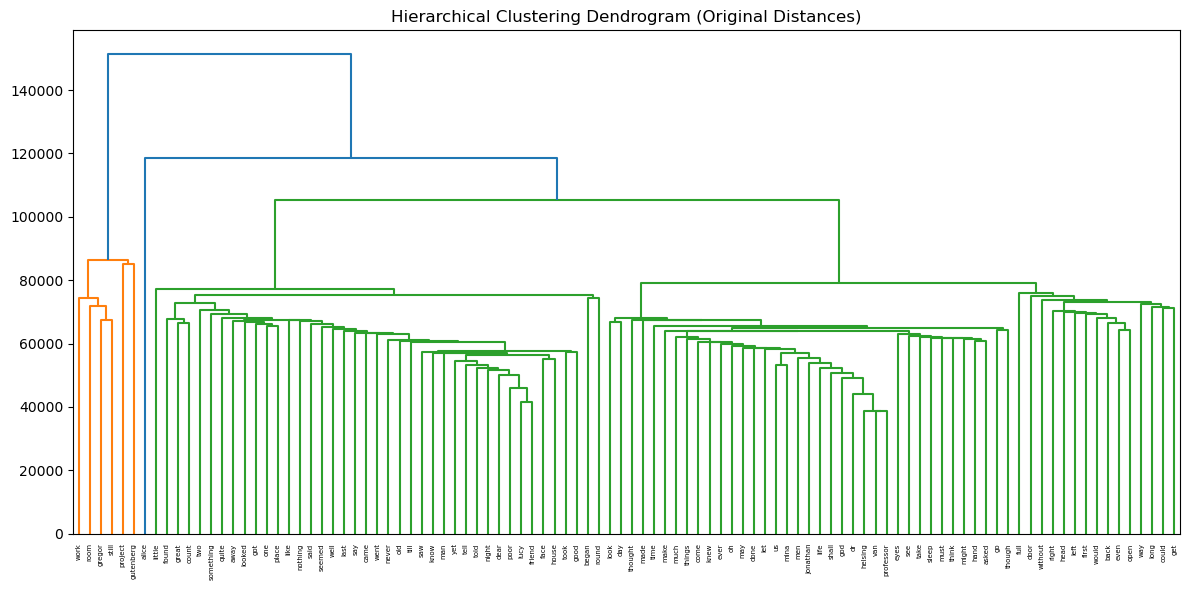

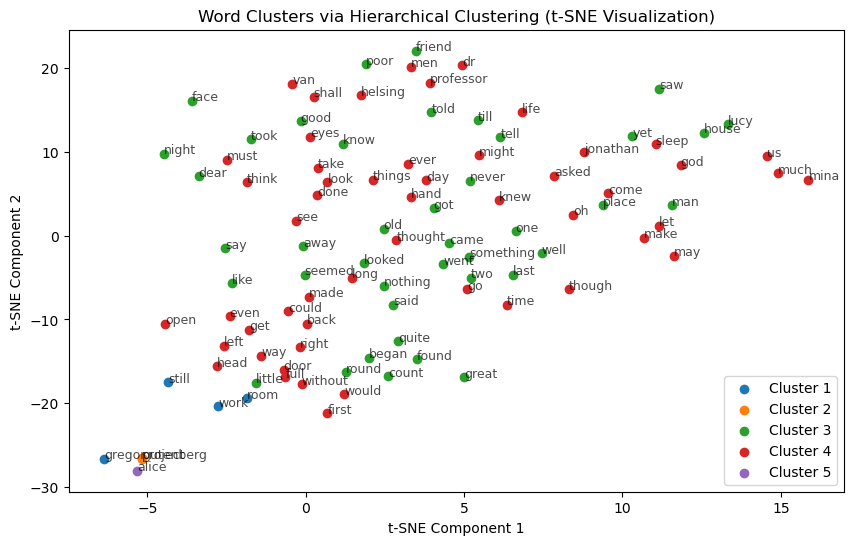

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE

# Convert word distance dictionary into a symmetric matrix
words_list = list(common_words)
distance_matrix = np.array([[word_distances[w1][w2] for w2 in words_list] for w1 in words_list])

# Replace 'inf' with a large value
max_distance = np.nanmax(distance_matrix[distance_matrix != float('inf')])
distance_matrix[distance_matrix == float('inf')] = max_distance

# Convert distance matrix to condensed form (required by linkage)
condensed_distance = squareform(distance_matrix, checks=False)

# Perform hierarchical clustering
Z = linkage(condensed_distance, method='ward')  # You can also try 'average', 'complete'

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=words_list, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Original Distances)")
plt.tight_layout()
plt.show()

# Assign flat clusters (e.g., k=5 clusters)
num_clusters = 5
flat_clusters = fcluster(Z, num_clusters, criterion='maxclust')

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, perplexity=5, learning_rate=100, random_state=42)
reduced_data = tsne.fit_transform(distance_matrix)

# Plot flat clusters
plt.figure(figsize=(10, 6))
for cluster_id in np.unique(flat_clusters):
    cluster_points = reduced_data[np.array(flat_clusters) == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id}")

# Annotate
for i, word in enumerate(words_list):
    plt.annotate(word, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=9, alpha=0.7)

plt.title("Word Clusters via Hierarchical Clustering (t-SNE Visualization)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()


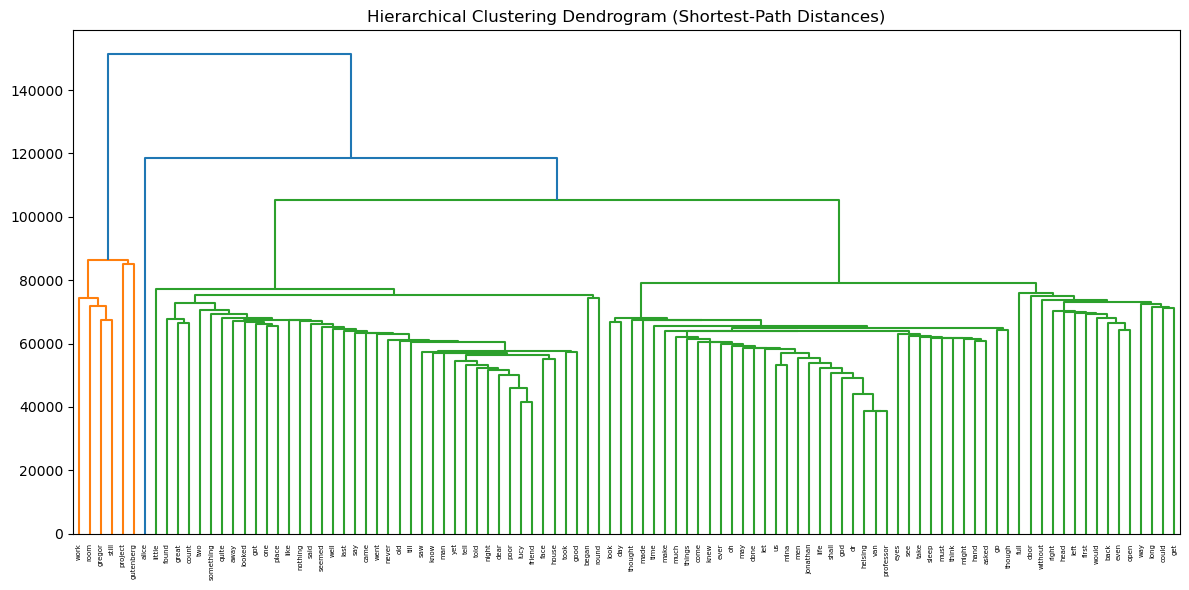

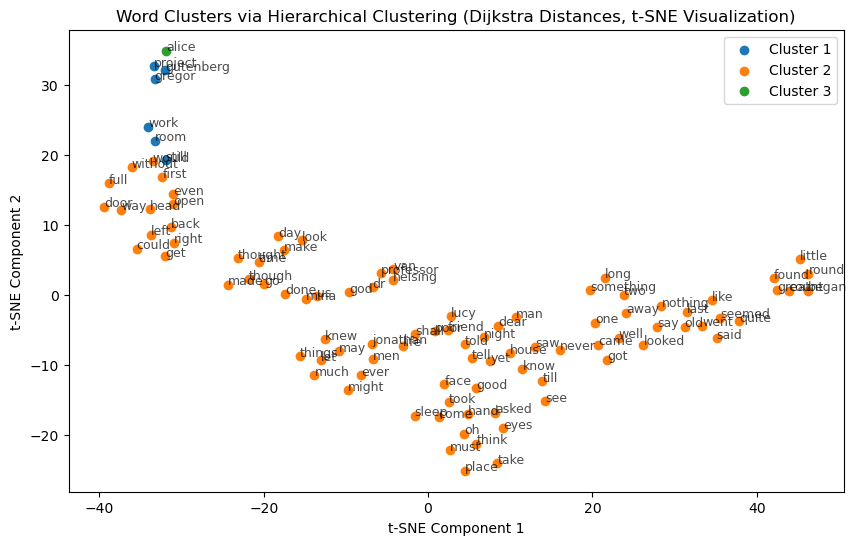

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE

# Build shortest-path distance matrix
shortest_path_matrix = np.array([[shortest_paths[w1].get(w2, float('inf')) for w2 in words_list] for w1 in words_list])
shortest_path_matrix[shortest_path_matrix == float('inf')] = max_distance

# Convert to condensed form
condensed_shortest = squareform(shortest_path_matrix, checks=False)

# Perform hierarchical clustering
Z_dijkstra = linkage(condensed_shortest, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z_dijkstra, labels=words_list, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Shortest-Path Distances)")
plt.tight_layout()
plt.show()

# Flat clusters (e.g., k=3 here)
num_clusters_dijkstra = 3
flat_clusters_dijkstra = fcluster(Z_dijkstra, num_clusters_dijkstra, criterion='maxclust')

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, perplexity=5, learning_rate=100, random_state=42)
reduced_shortest = tsne.fit_transform(shortest_path_matrix)

# Plot flat clusters
plt.figure(figsize=(10, 6))
for cluster_id in np.unique(flat_clusters_dijkstra):
    cluster_points = reduced_shortest[np.array(flat_clusters_dijkstra) == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id}")

# Annotate
for i, word in enumerate(words_list):
    plt.annotate(word, (reduced_shortest[i, 0], reduced_shortest[i, 1]), fontsize=9, alpha=0.7)

plt.title("Word Clusters via Hierarchical Clustering (Dijkstra Distances, t-SNE Visualization)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()


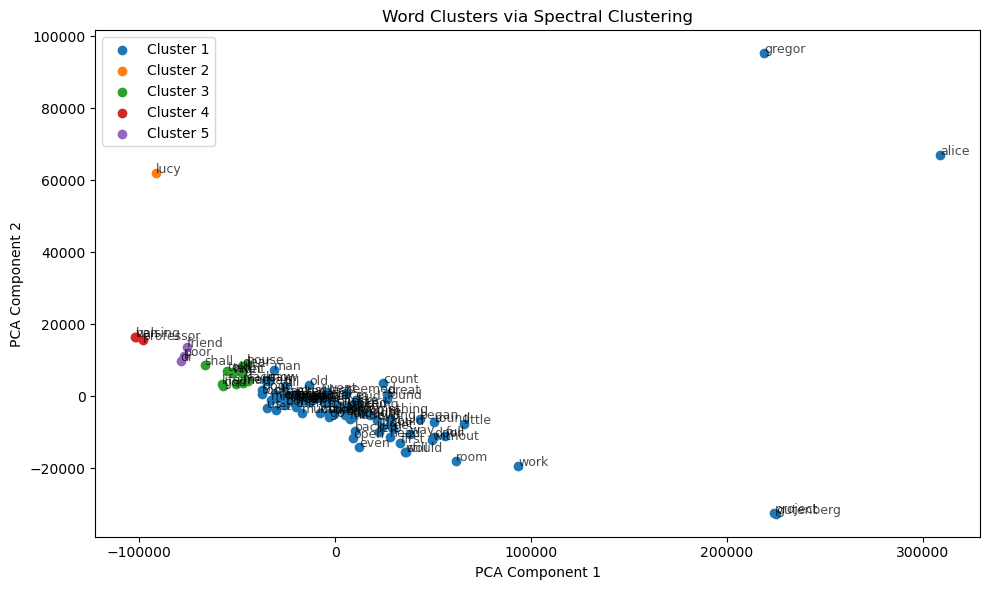

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel

# Convert word distance dictionary into a symmetric matrix
words_list = list(common_words)
distance_matrix = np.array([[word_distances[w1][w2] for w2 in words_list] for w1 in words_list])

# Replace 'inf' with a large value
max_distance = np.nanmax(distance_matrix[distance_matrix != float('inf')])
distance_matrix[distance_matrix == float('inf')] = max_distance

# Convert distance matrix to a similarity matrix using RBF kernel (or inverse)
# Smaller distances → higher similarity
gamma = 1.0 / (2.0 * np.std(distance_matrix)**2)  # Adjust as needed
similarity_matrix = rbf_kernel(distance_matrix, gamma=gamma)

# Apply Spectral Clustering
num_clusters = 5  # You can adjust this
spectral = SpectralClustering(
    n_clusters=num_clusters,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42
)
clusters = spectral.fit_predict(similarity_matrix)

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(distance_matrix)

# Plot clusters
plt.figure(figsize=(10, 6))
for cluster_id in np.unique(clusters):
    cluster_points = reduced_data[clusters == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id + 1}")

# Annotate
for i, word in enumerate(words_list):
    plt.annotate(word, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=9, alpha=0.7)

plt.title("Word Clusters via Spectral Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\mehak\anaconda3\envs\text_analytics\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


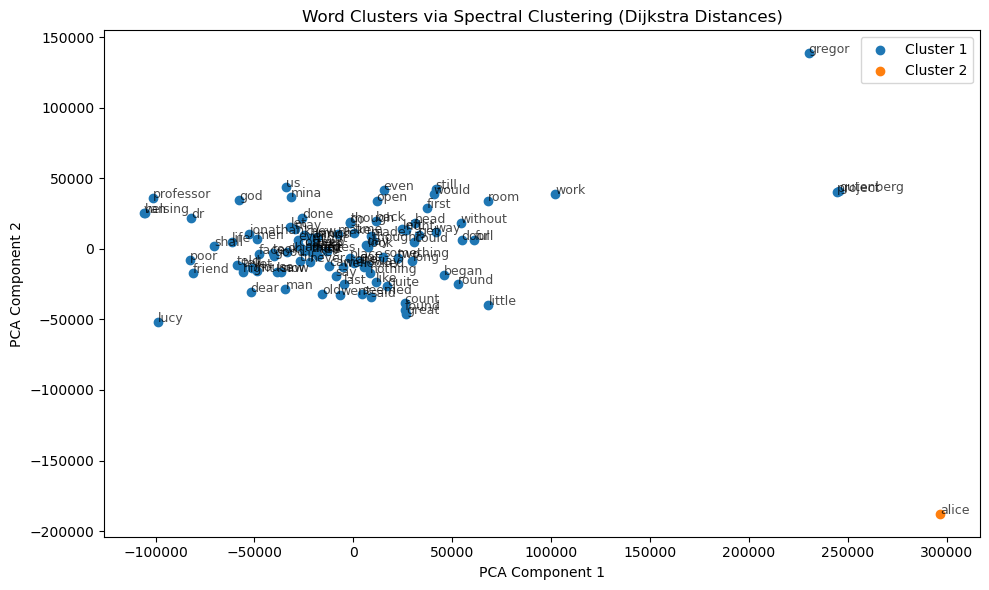

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel

# Convert shortest_paths dictionary to a matrix
words_list = list(common_words)
shortest_path_matrix = np.array([
    [shortest_paths[w1].get(w2, float('inf')) for w2 in words_list]
    for w1 in words_list
])

# Replace 'inf' with a large value
max_distance = np.nanmax(shortest_path_matrix[shortest_path_matrix != float('inf')])
shortest_path_matrix[shortest_path_matrix == float('inf')] = max_distance

# Convert distance matrix to similarity matrix (RBF kernel)
gamma = 1.0 / (2.0 * np.std(shortest_path_matrix)**2)
similarity_matrix = rbf_kernel(shortest_path_matrix, gamma=gamma)

# Apply Spectral Clustering
num_clusters = 5  # Adjust as needed
spectral = SpectralClustering(
    n_clusters=num_clusters,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42
)
clusters = spectral.fit_predict(similarity_matrix)

# PCA for visualization
reduced_data = PCA(n_components=2).fit_transform(shortest_path_matrix)

# Plot clusters
plt.figure(figsize=(10, 6))
for cluster_id in np.unique(clusters):
    cluster_points = reduced_data[clusters == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id + 1}")

# Annotate words
for i, word in enumerate(words_list):
    plt.annotate(word, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=9, alpha=0.7)

plt.title("Word Clusters via Spectral Clustering (Dijkstra Distances)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()


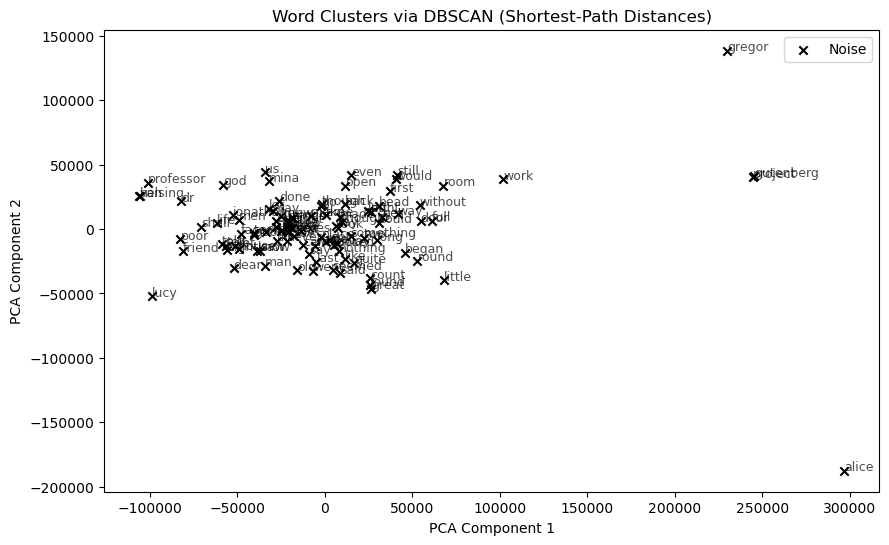

In [24]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN on the distance matrix
# eps: max distance between two samples for one to be considered as in the neighborhood of the other
# min_samples: minimum number of points to form a dense region (cluster)
dbscan = DBSCAN(eps=1.5, min_samples=2, metric='precomputed')  # You may need to tune eps
dbscan_labels = dbscan.fit_predict(shortest_path_matrix)

# PCA for visualization
reduced_dbscan = PCA(n_components=2).fit_transform(shortest_path_matrix)

# Plot DBSCAN clusters
plt.figure(figsize=(10, 6))
unique_labels = np.unique(dbscan_labels)

for label in unique_labels:
    cluster_points = reduced_dbscan[dbscan_labels == label]
    if label == -1:
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c='k', label="Noise", marker='x')
    else:
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {label}")

# Annotate
for i, word in enumerate(words_list):
    plt.annotate(word, (reduced_dbscan[i, 0], reduced_dbscan[i, 1]), fontsize=9, alpha=0.7)

plt.title("Word Clusters via DBSCAN (Shortest-Path Distances)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()
